# 01. ???????? ???????? ??????

????? 1-2: ????????, split, QC, ???????? YOLO ? ??????? test.

In [1]:
from pathlib import Path
import json
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

RAW_DIR = ROOT / 'data' / 'raw' / 'number_car_detect'
YOLO_DIR = ROOT / 'data' / 'processed' / 'detection_yolo'
QC_DIR = ROOT / 'outputs' / 'detection' / 'label_qc'
RUN_DETECTION_TRAINING = False

print('ROOT:', ROOT)
print('Raw images:', len(list(RAW_DIR.glob('*.jpg'))))
print('YOLO dataset exists:', YOLO_DIR.exists())

ROOT: C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_01
Raw images: 22
YOLO dataset exists: True


## 1. YOLO-????????

?????? label: `class_id x_center y_center width height`. ????? ????: `license_plate = 0`.

In [2]:
metadata_path = YOLO_DIR / 'metadata.json'
metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
summary = pd.DataFrame([
    {'metric': 'total_source_images', 'value': metadata['total_source_images']},
    {'metric': 'labeled_images', 'value': metadata['labeled_images']},
    {'metric': 'label_fraction', 'value': metadata['label_fraction']},
    {'metric': 'total_boxes', 'value': metadata['total_boxes']},
    {'metric': 'zero_box_images', 'value': metadata['zero_box_images']},
    {'metric': 'qc_images', 'value': metadata['qc_images']},
])
display(summary)

display(pd.DataFrame([
    {'split': split, **values} for split, values in metadata['split'].items()
]))
print('YOLO config:', YOLO_DIR / 'dataset.yaml')

,metric,value
0,total_source_images,368.0
1,labeled_images,368.0
2,label_fraction,1.0
3,total_boxes,337.0
4,zero_box_images,31.0
5,qc_images,337.0


,split,images,boxes,empty_labels
0,train,258,234,24
1,val,55,51,4
2,test,55,52,3


YOLO config: C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_01\data\processed\detection_yolo\dataset.yaml


## 2. QC ????????

????????? ??????? ? bbox.

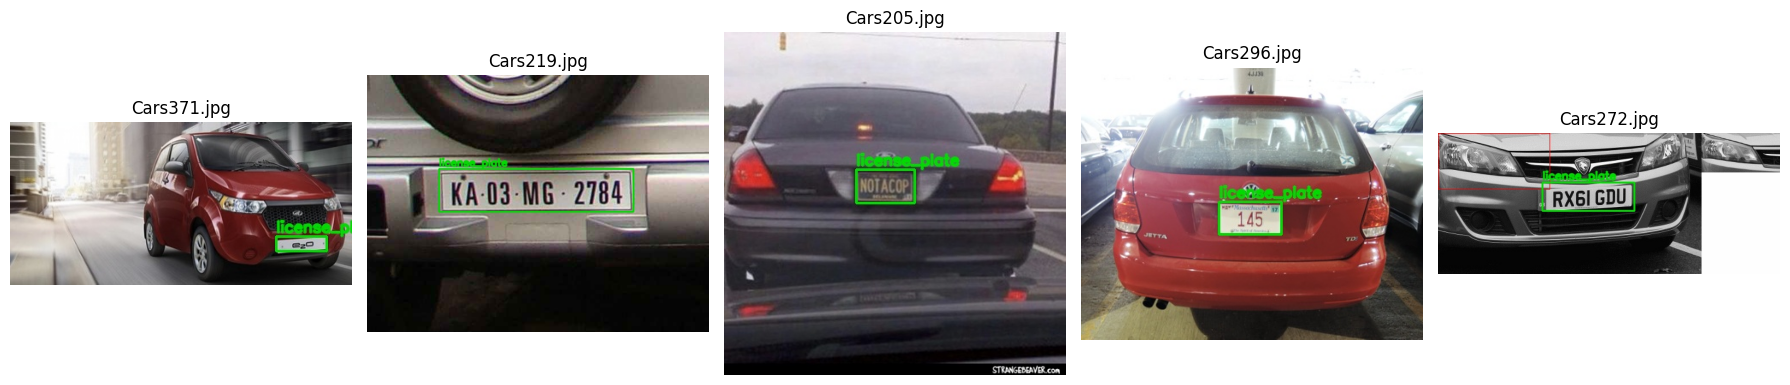

In [3]:
examples = ['Cars371.jpg', 'Cars219.jpg', 'Cars205.jpg', 'Cars296.jpg', 'Cars272.jpg']
fig, axes = plt.subplots(1, len(examples), figsize=(18, 4))
for ax, name in zip(axes, examples):
    img = cv2.imread(str(QC_DIR / name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. ???????? YOLO

????????? ?????? ?????????? ?????? `RUN_DETECTION_TRAINING = True`.

In [4]:
if RUN_DETECTION_TRAINING:
    from ultralytics import YOLO
    model = YOLO(str(ROOT / 'models' / 'pretrained' / 'yolov8n_license_plate_joker.pt'))
    results = model.train(
        data=str(YOLO_DIR / 'dataset.yaml'),
        epochs=12,
        imgsz=640,
        batch=8,
        device='cpu',
        seed=42,
        project=str(ROOT / 'outputs' / 'detection' / 'yolo_runs'),
        name='plate_detector',
        exist_ok=True,
    )
    print(results)
else:
    print('???????????? ??????? checkpoint:')
    print(ROOT / 'outputs' / 'detection' / 'yolo_runs' / 'plate_detector' / 'weights' / 'best.pt')

???????????? ??????? checkpoint:
C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_01\outputs\detection\yolo_runs\plate_detector\weights\best.pt


## 4. Test-???????

In [5]:
metrics_path = ROOT / 'outputs' / 'detection' / 'yolo_runs' / 'plate_detector' / 'test_metrics.json'
det_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
metrics = det_metrics['test_metrics']
display(pd.DataFrame([{
    'Precision': metrics['precision'],
    'Recall': metrics['recall'],
    'mAP@0.5': metrics['map50'],
    'mAP@0.5:0.95': metrics['map50_95'],
}]))

results_csv = ROOT / 'outputs' / 'detection' / 'yolo_runs' / 'plate_detector' / 'results.csv'
if results_csv.exists():
    display(pd.read_csv(results_csv).tail())

,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,0.960166,0.942308,0.988389,0.871646


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
7,8,473.350,0.63853,0.43559,0.93034,0.92365,0.96078,0.98442,0.86138,0.52200,0.36003,0.85613,0.000845,0.000845,0.000845
8,9,515.137,0.61354,0.42250,0.89757,0.95218,0.96078,0.98449,0.85238,0.57647,0.36857,0.85968,0.000680,0.000680,0.000680
9,10,557.977,0.60008,0.41299,0.89714,0.95285,0.96078,0.98477,0.87406,0.52195,0.36320,0.84922,0.000515,0.000515,0.000515
10,11,605.143,0.60643,0.40771,0.93009,0.95172,0.96078,0.98550,0.87186,0.48807,0.35598,0.84455,0.000350,0.000350,0.000350
11,12,654.867,0.56967,0.39546,0.88795,0.95212,0.96078,0.98522,0.87145,0.49321,0.35392,0.84228,0.000185,0.000185,0.000185
